<a href="https://colab.research.google.com/github/pughbrennan02-ai/Diamond-Assignment/blob/main/Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [2]:
breast_cancer = load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

print("Target names:", breast_cancer.target_names)
print("Feature names:", breast_cancer.feature_names)

Target names: ['malignant' 'benign']
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [3]:
print("Sample/feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Sample/feature matrix shape: (569, 30)
Target vector shape: (569,)
Number of samples: 569
Number of features: 30


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=11
)

In [5]:
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (426, 30)
X_test shape:  (143, 30)
y_train shape: (426,)
y_test shape:  (143,)


In [6]:
nb = GaussianNB()
nb

GaussianNB()

In [7]:
nb.fit(X_train, y_train)

GaussianNB()

In [8]:
predicted = nb.predict(X_test)

print("First 20 predictions:", predicted[:20])
print("First 20 expected values:", y_test[:20])

First 20 predictions: [0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0]
First 20 expected values: [0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0]


In [9]:
test_accuracy = nb.score(X_test, y_test)
print(f"GaussianNB test accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")

GaussianNB test accuracy: 0.9510 (95.10%)


In [10]:
cm = confusion_matrix(y_test, predicted)
print(cm)

[[44  6]
 [ 1 92]]


In [11]:
print(classification_report(
    y_test,
    predicted,
    target_names=breast_cancer.target_names,
))

              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



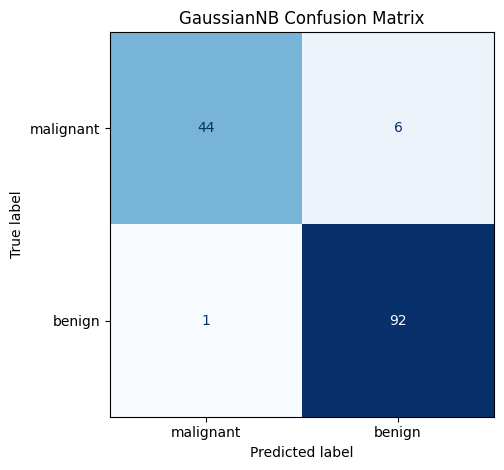

In [12]:
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=breast_cancer.target_names,
)
display.plot(cmap="Blues", colorbar=False)
plt.title("GaussianNB Confusion Matrix")
plt.tight_layout()
plt.show()

In [13]:
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

scores = cross_val_score(
    estimator=nb,
    X=breast_cancer.data,
    y=breast_cancer.target,
    cv=kfold,
)

print("Fold scores:", np.round(scores, 4))
print(f"Mean accuracy: {scores.mean():.4f}")
print(f"Accuracy standard deviation: {scores.std():.4f}")

Fold scores: [0.9649 0.9123 0.9474 0.8947 0.9649 0.9474 0.9649 0.8947 0.9649 0.9286]
Mean accuracy: 0.9385
Accuracy standard deviation: 0.0275


In [15]:
estimators = {
    'GaussianNB': nb,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(
        solver='lbfgs', multi_class='ovr', max_iter=10000
    ),
    'SVC': SVC(gamma='scale'),
}

model_results = {}

for estimator_name, estimator_object in estimators.items():
    # multi_class='ovr' is included because it is specified in the exercise.
    # Suppress only the version-dependent deprecation warning for cleaner
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        model_scores = cross_val_score(
            estimator=estimator_object,
            X=breast_cancer.data,
            y=breast_cancer.target,
            cv=kfold,
        )
    model_results[estimator_name] = model_scores.mean()
    print(f"{estimator_name:25} mean={model_scores.mean():.4f} "
          f"std={model_scores.std():.4f}")

best_model = max(model_results, key=model_results.get)
print(f"\nBest model: {best_model}")
print(f"Best mean accuracy: {model_results[best_model]:.4f}")

GaussianNB                mean=0.9385 std=0.0275
KNeighborsClassifier      mean=0.9279 std=0.0201
LogisticRegression        mean=0.9508 std=0.0302
SVC                       mean=0.9192 std=0.0352

Best model: LogisticRegression
Best mean accuracy: 0.9508
